# Getting Started Guide 1

This notebook gives a minimal end-to-end example of the seed-guided semi-supervised clustering method on a synthetic dataset.

The example is chosen to illustrate a setting where:
- clusters are mostly separated, but not perfectly isolated
- seed labels are sparse
- some points are genuine anomalies or are left unassigned
- the method is allowed to keep rejected points as label `-1`

If you are running from a local checkout of the repository, the cells below import the package directly from the repo.

## Imports And Setup

In [9]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make the project root importable when running the notebook from the repo.
notebook_dir = Path.cwd()
root_path = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

In [10]:
from clustering_nassir import SemiSupervisedClusterer
from utilities.generate_load_data import load_dataset
from utilities.plotting import plot_clusters

## Choose A Dataset Configuration

For a first walkthrough, `2d_gauss` is a good default because it is easy to visualise.

In [11]:
dataset_name = "2d_gauss"
random_seed = 43
k = 8
percent_labelled = 0.01
standardise = False

## Load The Data

The loaded dataframe contains:
- feature columns such as `f0`, `f1`
- `y_true`: the ground-truth label used for visual inspection and evaluation
- `y_live`: the sparse seed labels provided to the clustering method, with `-1` meaning unlabelled

In [12]:
df, num_clusters, plot_title, feature_columns = load_dataset(
    dataset_name=dataset_name,
    random_seed=random_seed,
    k=k,
    percent_labelled=percent_labelled,
    standardise=standardise,
)

dataset_summary = pd.Series(
    {
        "dataset": dataset_name,
        "n_examples": len(df),
        "n_features": len(feature_columns),
        "n_seeded_points": int((df["y_live"] != -1).sum()),
        "seed_fraction": round((df["y_live"] != -1).mean(), 4),
        "feature_columns": ", ".join(feature_columns),
    }
)

dataset_summary

dataset            2d_gauss
n_examples            10300
n_features                2
n_seeded_points         100
seed_fraction        0.0097
feature_columns      f0, f1
dtype: object

In [13]:
df.head()

,f0,f1,y_true,y_live
0,-3.577115,7.409740,2,-1
1,-7.496777,2.719674,0,-1
2,-3.554719,7.132534,2,-1
3,-6.976751,5.938354,4,-1
4,-5.527477,-8.477739,6,-1


## Visualise The Ground Truth And Seed Labels

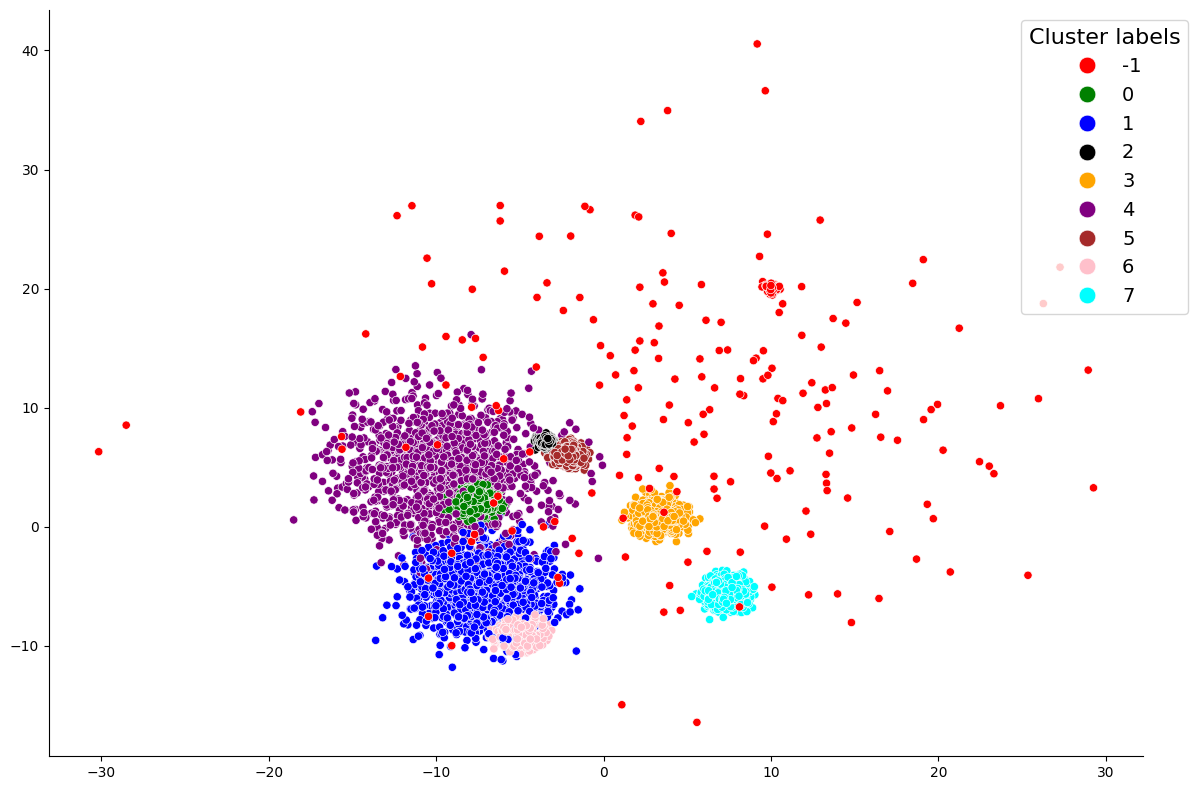

In [14]:
plot_clusters(
    df,
    feature_columns,
    label_column="y_true",
    title=plot_title,
    show_seeds_only=False,
);

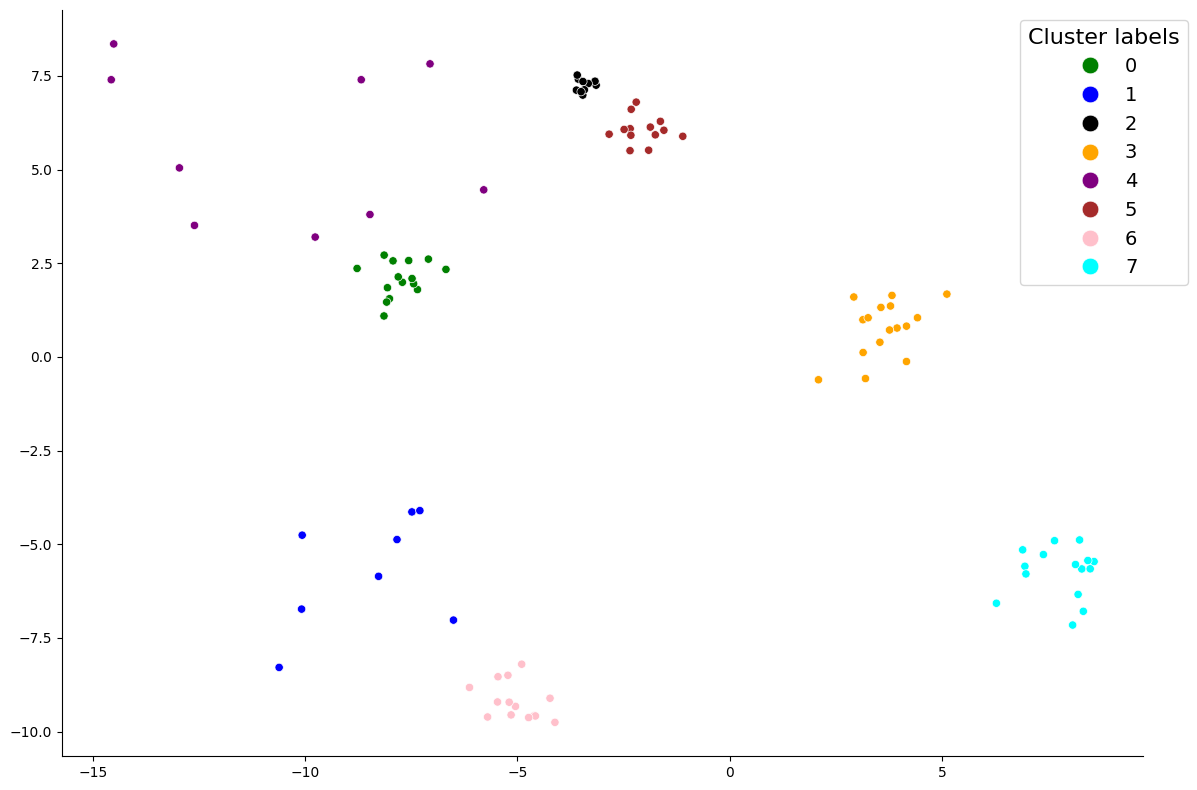

In [15]:
plot_clusters(
    df,
    feature_columns,
    label_column="y_live",
    title=f"{dataset_name} (seed labels only)",
    show_seeds_only=True,
);

## Run The Semi-Supervised Clusterer

The model expects a numeric array whose final column contains the seed labels.

In [16]:
df_result = df.copy()
X_with_seeds = df_result[feature_columns + ["y_live"]].to_numpy()

model = SemiSupervisedClusterer()
start = time.perf_counter()
df_result["novel_method"] = model.fit(X_with_seeds)
elapsed_seconds = time.perf_counter() - start

pd.Series(
    {
        "runtime_seconds": round(elapsed_seconds, 3),
        "n_predicted_clusters_excluding_-1": int(df_result.loc[df_result["novel_method"] != -1, "novel_method"].nunique()),
        "n_rejected_points": int((df_result["novel_method"] == -1).sum()),
        "rejection_rate": round((df_result["novel_method"] == -1).mean(), 4),
    }
)

runtime_seconds                        0.1050
n_predicted_clusters_excluding_-1      8.0000
n_rejected_points                    527.0000
rejection_rate                         0.0512
dtype: float64

## Inspect The Output Labels

In [17]:
label_summary = pd.DataFrame(
    {
        "true_count": df_result["y_true"].value_counts().sort_index(),
        "seed_count": df_result["y_live"].value_counts().sort_index(),
        "predicted_count": df_result["novel_method"].value_counts().sort_index(),
    }
).fillna(0).astype(int)

label_summary

,true_count,seed_count,predicted_count
-1,300,10200,527
0,1250,15,1116
1,1250,8,1170
2,1250,10,1097
3,1250,16,1149
4,1250,9,1667
5,1250,13,1155
6,1250,14,1217
7,1250,15,1202


In [18]:
df_result[df_result["novel_method"] == -1].head()

,f0,f1,y_true,y_live,novel_method
309,4.828440,0.013213,3,-1,-1
313,-5.666619,-10.135958,6,-1,-1
378,-6.472325,-9.940071,6,-1,-1
439,1.757311,1.704708,3,-1,-1
462,1.896992,1.565474,3,-1,-1


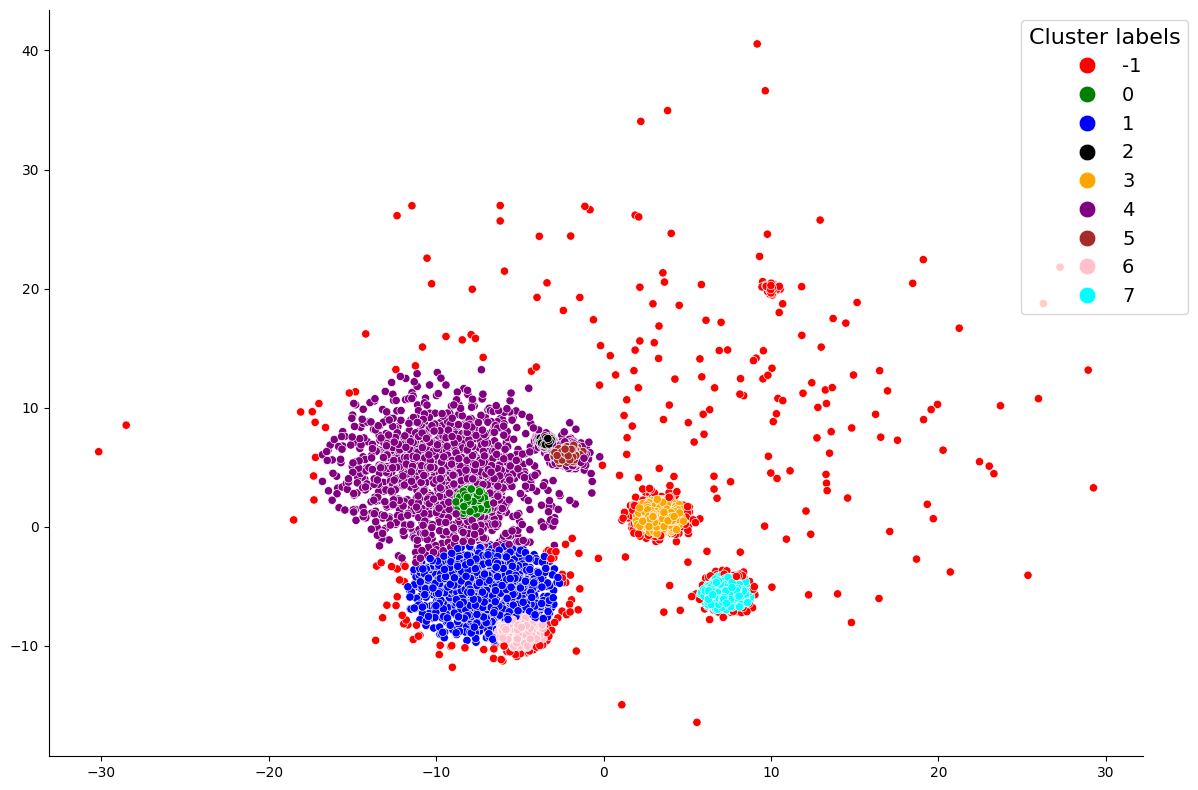

In [19]:
plot_clusters(
    df_result,
    feature_columns,
    label_column="novel_method",
    title=f"Semi-supervised clustering result: {dataset_name}",
    show_seeds_only=False,
);

## Next Steps

Once this basic workflow is clear, the next notebook to open is `getting_started_guide_2.ipynb`, which compares the proposed method against several baseline clustering methods and computes evaluation metrics.